# 01 - REINFORCE con Value Baseline

Questo notebook confronta tre varianti di REINFORCE su CartPole:

1. REINFORCE **senza** standardizzazione dei ritorni.
2. REINFORCE **con** standardizzazione dei ritorni come baseline semplice indipendente dallo stato.
3. REINFORCE **con value baseline** appresa $V(s)$.

Il confronto usa 5 seed, valutazione periodica deterministica e valutazione finale su 10 episodi usando il miglior checkpoint osservato per ogni run.

## Setup

Importiamo le librerie essenziali, agganciamo la repository principale e carichiamo le funzioni di addestramento e valutazione definite nei moduli `DLA_LAB3/src`.


In [1]:
from pathlib import Path
import sys

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml

current_dir = Path.cwd().resolve()
for candidate in [current_dir, *current_dir.parents]:
    if (candidate / "DLA_LAB3" / "src").exists():
        project_root = candidate
        break
else:
    raise RuntimeError("Eseguire il notebook dalla repository Deep_Learning_Laboratories.")

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from DLA_LAB3.src.evaluation import evaluate_policy, render_policy
from DLA_LAB3.src.networks import PolicyNetwork, ValueNetwork
from DLA_LAB3.src.reinforce import train_reinforce, train_reinforce_with_value_baseline
from DLA_LAB3.src.utils import get_device, restore_model_state, seed_environment, set_seed

In [2]:
config_path = project_root / "DLA_LAB3" / "exercise_2_value_baseline" / "config.yaml"
raw_config = yaml.safe_load(config_path.read_text())

CONFIG = {
    "environment_name": raw_config["environment"]["name"],
    "max_steps": raw_config["environment"]["max_steps"],
    "seeds": raw_config["training"]["seeds"],
    "num_episodes": raw_config["training"]["num_episodes"],
    "gamma": raw_config["training"]["gamma"],
    "policy_learning_rate": raw_config["training"]["policy_learning_rate"],
    "value_learning_rate": raw_config["training"]["value_learning_rate"],
    "hidden_dim": raw_config["training"]["hidden_dim"],
    "force_cpu": raw_config["training"]["force_cpu"],
    "standardize_returns": raw_config["comparison"]["standardize_returns"],
    "eval_episodes": raw_config["evaluation"]["num_episodes"],
    "deterministic_eval": raw_config["evaluation"]["deterministic"],
    "eval_interval": raw_config["evaluation"]["eval_every_n"],
}

for key, value in CONFIG.items():
    print(f"{key}: {value}")


environment_name: CartPole-v1
max_steps: 500
seeds: [42, 123, 314, 2024, 9001]
num_episodes: 300
gamma: 0.99
policy_learning_rate: 0.001
value_learning_rate: 0.001
hidden_dim: 128
force_cpu: True
standardize_returns: True
eval_episodes: 10
deterministic_eval: True
eval_interval: 20


## Device

Il training forza l'uso della CPU: per una rete piccola come quella di CartPole, il calcolo su CPU risulta più rapido rispetto a GPU.

In [3]:
device = get_device(force_cpu=CONFIG["force_cpu"])
print("Using device:", device)


Using device: cpu


## Baseline e advantage

La standardizzazione sottrae la media e divide per la deviazione standard dei ritorni nell'episodio: costituisce una baseline semplice, indipendente dallo stato. Prima di introdurre la value baseline, confrontiamo REINFORCE senza e con questa trasformazione.

Nel primo esercizio la policy viene aggiornata usando direttamente il ritorno $G_t$ (eventualmente standardizzato).

Qui aggiungo anche una value network $V(s)$ e uso il vantaggio:

$$A_t = G_t - V(s_t)$$

La value network viene addestrata con errore quadratico medio sui ritorni osservati.

## Controllo dell'ambiente

Verifichiamo rapidamente le proprietà dello spazio delle osservazioni e delle azioni sull'ambiente CartPole-v1.


In [4]:
env_check = gym.make(CONFIG["environment_name"])
observation, info = seed_environment(env_check, CONFIG["seeds"][0])

print("Observation iniziale:", observation)
print("Observation space:", env_check.observation_space)
print("Action space:", env_check.action_space)
print("Info reset:", info)

observation_dim = env_check.observation_space.shape[0]
action_dim = env_check.action_space.n
env_check.close()


Observation iniziale: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space: Discrete(2)
Info reset: {}


## Confronto multi-seed

Per ogni seed addestro tre agenti:

1. REINFORCE senza standardizzazione dei ritorni.
2. REINFORCE standard (con standardizzazione dei ritorni).
3. REINFORCE con value baseline.

Ogni 20 episodi valuto la policy in modo deterministico per 10 episodi. Per la valutazione finale ripristino il miglior checkpoint osservato durante queste valutazioni.

In [5]:
nostd_training_results = {}
std_training_results = {}
base_training_results = {}
trained_base_policies = {}
summary_rows = []

print(f"Confronto multi-seed su {len(CONFIG['seeds'])} seed: {CONFIG['seeds']}...")

for seed in CONFIG["seeds"]:
    print(f"Run seed {seed}")

    # --- 1. Variante REINFORCE senza standardizzazione dei ritorni ---
    set_seed(seed)
    nostd_train_env = gym.make(CONFIG["environment_name"])
    seed_environment(nostd_train_env, seed)
    nostd_policy = PolicyNetwork(observation_dim, action_dim, CONFIG["hidden_dim"]).to(device)
    nostd_optimizer = torch.optim.Adam(nostd_policy.parameters(), lr=CONFIG["policy_learning_rate"])

    nostd_eval_env = gym.make(CONFIG["environment_name"])
    seed_environment(nostd_eval_env, seed)

    nostd_res = train_reinforce(
        env=nostd_train_env,
        policy=nostd_policy,
        optimizer=nostd_optimizer,
        device=device,
        num_episodes=CONFIG["num_episodes"],
        gamma=CONFIG["gamma"],
        standardize_returns=False,
        eval_env=nostd_eval_env,
        eval_every_n=CONFIG["eval_interval"],
        eval_episodes_m=CONFIG["eval_episodes"],
    )
    nostd_train_env.close()
    nostd_eval_env.close()

    restore_model_state(nostd_policy, nostd_res.best_policy_state)

    nostd_eval_final_env = gym.make(CONFIG["environment_name"])
    seed_environment(nostd_eval_final_env, seed)
    nostd_eval = evaluate_policy(nostd_eval_final_env, nostd_policy, device, CONFIG["eval_episodes"], CONFIG["max_steps"], CONFIG["deterministic_eval"])
    nostd_eval_final_env.close()

    nostd_training_results[seed] = nostd_res
    summary_rows.append({
        "Modello": "REINFORCE Senza Standardizzazione",
        "Seed": seed,
        "Final Train Reward": round(nostd_res.episode_rewards[-1], 1),
        "Best Train Reward": round(max(nostd_res.episode_rewards), 1),
        "Eval Mean Reward": round(nostd_eval["mean_reward"], 1),
        "Eval Min Reward": round(nostd_eval["min_reward"], 1),
        "Eval Max Reward": round(nostd_eval["max_reward"], 1),
        "Eval Mean Length": round(nostd_eval["mean_length"], 1),
        "Best Checkpoint Episode": nostd_res.best_eval_episode,
        "Best Checkpoint Reward": round(nostd_res.best_eval_mean_reward, 1),
    })

    # --- 2. Variante REINFORCE standard (con standardizzazione dei ritorni) ---
    set_seed(seed)
    std_train_env = gym.make(CONFIG["environment_name"])
    seed_environment(std_train_env, seed)
    std_policy = PolicyNetwork(observation_dim, action_dim, CONFIG["hidden_dim"]).to(device)
    std_optimizer = torch.optim.Adam(std_policy.parameters(), lr=CONFIG["policy_learning_rate"])
    
    std_eval_env = gym.make(CONFIG["environment_name"])
    seed_environment(std_eval_env, seed)
    
    std_res = train_reinforce(
        env=std_train_env,
        policy=std_policy,
        optimizer=std_optimizer,
        device=device,
        num_episodes=CONFIG["num_episodes"],
        gamma=CONFIG["gamma"],
        standardize_returns=CONFIG["standardize_returns"],
        eval_env=std_eval_env,
        eval_every_n=CONFIG["eval_interval"],
        eval_episodes_m=CONFIG["eval_episodes"],
    )
    std_train_env.close()
    std_eval_env.close()
    
    restore_model_state(std_policy, std_res.best_policy_state)

    std_eval_final_env = gym.make(CONFIG["environment_name"])
    seed_environment(std_eval_final_env, seed)
    std_eval = evaluate_policy(std_eval_final_env, std_policy, device, CONFIG["eval_episodes"], CONFIG["max_steps"], CONFIG["deterministic_eval"])
    std_eval_final_env.close()
    
    std_training_results[seed] = std_res
    summary_rows.append({
        "Modello": "REINFORCE Standard",
        "Seed": seed,
        "Final Train Reward": round(std_res.episode_rewards[-1], 1),
        "Best Train Reward": round(max(std_res.episode_rewards), 1),
        "Eval Mean Reward": round(std_eval["mean_reward"], 1),
        "Eval Min Reward": round(std_eval["min_reward"], 1),
        "Eval Max Reward": round(std_eval["max_reward"], 1),
        "Eval Mean Length": round(std_eval["mean_length"], 1),
        "Best Checkpoint Episode": std_res.best_eval_episode,
        "Best Checkpoint Reward": round(std_res.best_eval_mean_reward, 1),
    })
    
    # --- 3. Variante REINFORCE con value baseline ---
    set_seed(seed)
    base_train_env = gym.make(CONFIG["environment_name"])
    seed_environment(base_train_env, seed)
    base_policy = PolicyNetwork(observation_dim, action_dim, CONFIG["hidden_dim"]).to(device)
    base_value = ValueNetwork(observation_dim, CONFIG["hidden_dim"]).to(device)
    base_policy_optimizer = torch.optim.Adam(base_policy.parameters(), lr=CONFIG["policy_learning_rate"])
    base_value_optimizer = torch.optim.Adam(base_value.parameters(), lr=CONFIG["value_learning_rate"])
    
    base_eval_env = gym.make(CONFIG["environment_name"])
    seed_environment(base_eval_env, seed)
    
    base_res = train_reinforce_with_value_baseline(
        env=base_train_env,
        policy=base_policy,
        value_network=base_value,
        policy_optimizer=base_policy_optimizer,
        value_optimizer=base_value_optimizer,
        device=device,
        num_episodes=CONFIG["num_episodes"],
        gamma=CONFIG["gamma"],
        eval_env=base_eval_env,
        eval_every_n=CONFIG["eval_interval"],
        eval_episodes_m=CONFIG["eval_episodes"],
    )
    base_train_env.close()
    base_eval_env.close()
    
    restore_model_state(base_policy, base_res.best_policy_state)
    restore_model_state(base_value, base_res.best_value_state)

    base_eval_final_env = gym.make(CONFIG["environment_name"])
    seed_environment(base_eval_final_env, seed)
    base_eval = evaluate_policy(base_eval_final_env, base_policy, device, CONFIG["eval_episodes"], CONFIG["max_steps"], CONFIG["deterministic_eval"])
    base_eval_final_env.close()
    
    base_training_results[seed] = base_res
    trained_base_policies[seed] = base_policy
    summary_rows.append({
        "Modello": "REINFORCE + Value Baseline",
        "Seed": seed,
        "Final Train Reward": round(base_res.episode_rewards[-1], 1),
        "Best Train Reward": round(max(base_res.episode_rewards), 1),
        "Eval Mean Reward": round(base_eval["mean_reward"], 1),
        "Eval Min Reward": round(base_eval["min_reward"], 1),
        "Eval Max Reward": round(base_eval["max_reward"], 1),
        "Eval Mean Length": round(base_eval["mean_length"], 1),
        "Best Checkpoint Episode": base_res.best_eval_episode,
        "Best Checkpoint Reward": round(base_res.best_eval_mean_reward, 1),
    })

results_table = pd.DataFrame(summary_rows)
print("\nTraining completato su tutti i seed.")


Confronto multi-seed su 5 seed: [42, 123, 314, 2024, 9001]...
Run seed 42
Run seed 123
Run seed 314
Run seed 2024
Run seed 9001

Training completato su tutti i seed.


## Risultati

La tabella riporta i risultati finali per seed dopo il ripristino del miglior checkpoint in memoria.

La sintesi aggregata usa reward medio, deviazione standard e lunghezza media degli episodi di valutazione.

In [6]:
model_order = ["REINFORCE Senza Standardizzazione", "REINFORCE Standard", "REINFORCE + Value Baseline"]

display(results_table.sort_values(by=["Modello", "Seed"]).reset_index(drop=True))

print("\n--- Sintesi Statistica Aggregata sui 5 Seed ---")
aggregated_table = results_table.groupby("Modello").agg(
    Eval_Mean_Avg=("Eval Mean Reward", "mean"),
    Eval_Mean_Std=("Eval Mean Reward", "std"),
    Eval_Min_Global=("Eval Min Reward", "min"),
    Eval_Max_Global=("Eval Max Reward", "max"),
    Eval_Length_Avg=("Eval Mean Length", "mean"),
).round(1).reindex(model_order)

display(aggregated_table)

best_base_seed = int(results_table[results_table["Modello"] == "REINFORCE + Value Baseline"].sort_values("Eval Mean Reward", ascending=False).iloc[0]["Seed"])
best_base_policy = trained_base_policies[best_base_seed]
print(f"Seed migliore per REINFORCE + Value Baseline: {best_base_seed}")


,Modello,Seed,Final Train Reward,Best Train Reward,Eval Mean Reward,Eval Min Reward,Eval Max Reward,Eval Mean Length,Best Checkpoint Episode,Best Checkpoint Reward
0,REINFORCE + Value Baseline,42,500.0,500.0,500.0,500.0,500.0,500.0,160,500.0
1,REINFORCE + Value Baseline,123,500.0,500.0,500.0,500.0,500.0,500.0,220,500.0
2,REINFORCE + Value Baseline,314,500.0,500.0,500.0,500.0,500.0,500.0,280,492.8
3,REINFORCE + Value Baseline,2024,500.0,500.0,500.0,500.0,500.0,500.0,200,500.0
4,REINFORCE + Value Baseline,9001,432.0,500.0,499.7,497.0,500.0,499.7,160,500.0
5,REINFORCE Senza Standardizzazione,42,260.0,500.0,463.6,347.0,500.0,463.6,240,487.2
6,REINFORCE Senza Standardizzazione,123,32.0,500.0,500.0,500.0,500.0,500.0,240,500.0
7,REINFORCE Senza Standardizzazione,314,130.0,500.0,453.1,297.0,500.0,453.1,200,454.3
8,REINFORCE Senza Standardizzazione,2024,130.0,500.0,349.3,182.0,500.0,349.3,200,360.6
9,REINFORCE Senza Standardizzazione,9001,72.0,500.0,240.0,171.0,345.0,240.0,160,269.9



--- Sintesi Statistica Aggregata sui 5 Seed ---


,Eval_Mean_Avg,Eval_Mean_Std,Eval_Min_Global,Eval_Max_Global,Eval_Length_Avg
Modello,,,,,
REINFORCE Senza Standardizzazione,401.2,106.1,171.0,500.0,401.2
REINFORCE Standard,498.6,3.1,430.0,500.0,498.6
REINFORCE + Value Baseline,499.9,0.1,497.0,500.0,499.9


Seed migliore per REINFORCE + Value Baseline: 42


### Osservazioni

- Confrontare la riga "REINFORCE Senza Standardizzazione" con "REINFORCE Standard" nella tabella sopra isola l'effetto della sola standardizzazione dei ritorni.
- Confrontare "REINFORCE Standard" con "REINFORCE + Value Baseline" isola invece l'effetto della baseline appresa $V(s)$ rispetto alla baseline "semplice" di standardizzazione.
- REINFORCE + Value Baseline ha il reward medio aggregato più alto (499,9) e la deviazione standard più bassa (0,1) tra i 5 seed; REINFORCE Standard segue con media 498,6 e deviazione standard 3,1, mentre la variante senza standardizzazione ha media 401,2 e deviazione standard 106,1.
- Il minimo globale sui 5 seed migliora progressivamente: 171,0 senza standardizzazione, 430,0 con standardizzazione, 497,0 con value baseline.

## Curve di valutazione periodica

Mostro il reward medio di valutazione ogni 20 episodi.

Ogni punto è calcolato su 10 episodi deterministici. L'area ombreggiata rappresenta una deviazione standard sui 5 seed.

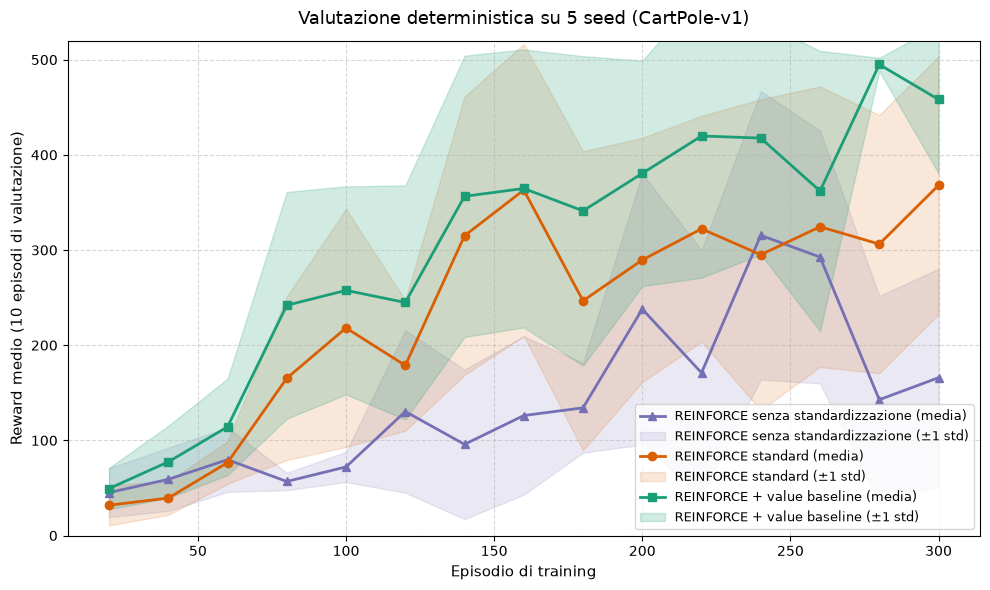

In [7]:
plt.figure(figsize=(10, 6))

eval_episodes_axis = std_training_results[CONFIG["seeds"][0]].eval_episodes

nostd_eval_matrix = np.array([res.eval_mean_rewards for res in nostd_training_results.values()])
nostd_mean = nostd_eval_matrix.mean(axis=0)
nostd_std = nostd_eval_matrix.std(axis=0)

std_eval_matrix = np.array([res.eval_mean_rewards for res in std_training_results.values()])
std_mean = std_eval_matrix.mean(axis=0)
std_std = std_eval_matrix.std(axis=0)

base_eval_matrix = np.array([res.eval_mean_rewards for res in base_training_results.values()])
base_mean = base_eval_matrix.mean(axis=0)
base_std = base_eval_matrix.std(axis=0)

plt.plot(eval_episodes_axis, nostd_mean, marker='^', linewidth=2, color='#7570b3', label='REINFORCE senza standardizzazione (media)')
plt.fill_between(eval_episodes_axis, nostd_mean - nostd_std, nostd_mean + nostd_std, color='#7570b3', alpha=0.15, label='REINFORCE senza standardizzazione (±1 std)')

plt.plot(eval_episodes_axis, std_mean, marker='o', linewidth=2, color='#d95f02', label='REINFORCE standard (media)')
plt.fill_between(eval_episodes_axis, std_mean - std_std, std_mean + std_std, color='#d95f02', alpha=0.15, label='REINFORCE standard (±1 std)')

plt.plot(eval_episodes_axis, base_mean, marker='s', linewidth=2, color='#1b9e77', label='REINFORCE + value baseline (media)')
plt.fill_between(eval_episodes_axis, base_mean - base_std, base_mean + base_std, color='#1b9e77', alpha=0.2, label='REINFORCE + value baseline (±1 std)')

plt.title('Valutazione deterministica su 5 seed (CartPole-v1)', fontsize=13, pad=12)
plt.xlabel('Episodio di training', fontsize=11)
plt.ylabel('Reward medio (10 episodi di valutazione)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=9, loc='lower right')
plt.ylim(0, 520)
plt.tight_layout()
plt.show()


### Osservazioni

- Nel grafico, il confronto con la curva "senza standardizzazione" mostra l'effetto della baseline semplice rispetto ai ritorni grezzi.
- Il confronto tra le tre curve permette di vedere separatamente l'effetto della standardizzazione e quello della value baseline sulla velocità di convergenza e sulla dispersione tra seed durante il training (non solo alla fine).
- REINFORCE + Value Baseline converge più rapidamente: supera già le altre due varianti entro l'episodio 100, mentre REINFORCE senza standardizzazione resta la più lenta per gran parte del training.
- La banda ±1 std della variante senza standardizzazione è la più ampia per la maggior parte del training (specialmente tra gli episodi 100 e 200); quella con value baseline si restringe progressivamente ed è la più stretta nella valutazione finale (deviazione standard aggregata 0,1 contro 3,1 e 106,1).

## Visualizzazione real time

Visualizzo la policy con value baseline del seed migliore nella valutazione finale.

In [8]:
baseline_render_rewards = render_policy(
    environment_name=CONFIG["environment_name"],
    policy=best_base_policy,
    device=device,
    num_episodes=3,
    max_steps=CONFIG["max_steps"],
    deterministic=True,
    frame_delay=0.02,
)
print("Reward episodi renderizzati:", baseline_render_rewards)


Reward episodi renderizzati: [500.0, 500.0, 500.0]


## Osservazioni finali

- Il confronto a tre vie isola separatamente l'effetto della standardizzazione dei ritorni e quello della value baseline appresa $V(s)$.
- La valutazione periodica usa reward medio e lunghezza media degli episodi.
- La standardizzazione dei ritorni è responsabile della gran parte della riduzione di varianza tra seed (deviazione standard da 106,1 a 3,1); la value baseline aggiunge un ulteriore miglioramento più piccolo ma misurabile (da 3,1 a 0,1).